# 04 - 网格交易策略研究与回测

本文件包含两种策略：
1. 传统网格交易（固定间距）
2. 自适应网格策略（按波动率动态调整网格间距）

支持选择股票、回测时间段、初始资金与交易成本。

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd()
for p in [cwd / 'src', cwd.parent / 'src']:
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

from quant_research.db import query_df

In [2]:
# 回测公共参数
symbol = 'US:AAPL'
start_date = '2023-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')
initial_capital = 1_000_000.0
fee_rate = 0.0003
slippage = 0.001
lot_size = 100

# 策略选择: 'classic_grid' 或 'adaptive_grid'
strategy_mode = 'classic_grid'

# 传统网格参数
classic_grid_params = {
    'grid_pct': 0.02,          # 网格间距（2%）
    'max_pos_ratio': 0.9,      # 最大仓位占比
    'min_cash_ratio': 0.1,     # 最小现金占比
}

# 自适应网格参数
adaptive_grid_params = {
    'base_grid_pct': 0.01,     # 基础网格
    'vol_window': 20,          # 波动率窗口
    'vol_scale': 1.5,          # 波动缩放
    'max_grid_pct': 0.05,      # 网格上限
    'min_grid_pct': 0.006,     # 网格下限
    'max_pos_ratio': 0.9,
    'min_cash_ratio': 0.1,
}

In [3]:
df = query_df(f"""
select trade_date, symbol, open, high, low, close, volume
from daily_bars
where symbol = '{symbol}'
  and trade_date between toDate('{start_date}') and toDate('{end_date}')
order by trade_date
""")
df['trade_date'] = pd.to_datetime(df['trade_date'])
df.head()

,trade_date,symbol,open,high,low,close,volume
0,2023-01-03,US:AAPL,128.223801,128.834011,122.210234,123.096031,112117500.0
1,2023-01-04,US:AAPL,124.887326,126.629395,123.105895,124.365692,89113600.0
2,2023-01-05,US:AAPL,125.123505,125.753403,122.790915,123.046806,80962700.0
3,2023-01-06,US:AAPL,124.021194,128.233635,122.918869,127.574211,87754700.0
4,2023-01-09,US:AAPL,128.410797,131.304398,127.839949,128.095840,70790800.0


In [4]:
def calc_metrics(curve: pd.Series, daily_ret: pd.Series, num_trades: int) -> dict:
    days = max(len(curve), 1)
    ann_factor = 252 / days
    total_return = float(curve.iloc[-1] - 1)
    cagr = (1 + total_return) ** ann_factor - 1
    mdd = float((curve / curve.cummax() - 1).min())
    sharpe = float(np.sqrt(252) * daily_ret.mean() / (daily_ret.std() + 1e-12))
    return {
        'total_return': total_return,
        'cagr': float(cagr),
        'max_drawdown': mdd,
        'sharpe': sharpe,
        'num_trades': int(num_trades),
    }


def run_grid_backtest(data: pd.DataFrame, mode: str) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    out = data.copy().reset_index(drop=True)
    out['ret'] = out['close'].pct_change().fillna(0.0)

    cash = float(initial_capital)
    shares = 0
    anchor = float(out['close'].iloc[0])
    trades = []

    # 初始买入 50% 资金
    init_price = float(out['open'].iloc[0]) * (1 + slippage)
    init_budget = initial_capital * 0.5
    init_q = int((init_budget / init_price) // lot_size) * lot_size
    if init_q > 0:
        fee = init_q * init_price * fee_rate
        cost = init_q * init_price + fee
        cash -= cost
        shares += init_q
        trades.append({'trade_date': out['trade_date'].iloc[0], 'side': 'BUY', 'price': init_price, 'shares': init_q, 'fee': fee, 'grid_pct': np.nan})

    eq_rows = []

    for i in range(len(out)):
        c = float(out['close'].iloc[i])
        o = float(out['open'].iloc[i])

        if mode == 'classic_grid':
            grid_pct = float(classic_grid_params['grid_pct'])
            max_pos_ratio = float(classic_grid_params['max_pos_ratio'])
            min_cash_ratio = float(classic_grid_params['min_cash_ratio'])
        else:
            vol = out['ret'].iloc[max(0, i - int(adaptive_grid_params['vol_window']) + 1):i + 1].std()
            base = float(adaptive_grid_params['base_grid_pct'])
            scale = float(adaptive_grid_params['vol_scale'])
            grid_pct = base * (1 + scale * (0 if pd.isna(vol) else vol * np.sqrt(252)))
            grid_pct = min(float(adaptive_grid_params['max_grid_pct']), max(float(adaptive_grid_params['min_grid_pct']), float(grid_pct)))
            max_pos_ratio = float(adaptive_grid_params['max_pos_ratio'])
            min_cash_ratio = float(adaptive_grid_params['min_cash_ratio'])

        lower = anchor * (1 - grid_pct)
        upper = anchor * (1 + grid_pct)

        equity_now = cash + shares * c
        pos_ratio = 0 if equity_now <= 0 else (shares * c / equity_now)
        cash_ratio = 0 if equity_now <= 0 else (cash / equity_now)

        # 触发买入：跌破下网格且现金充足
        if c <= lower and cash_ratio > min_cash_ratio:
            buy_price = o * (1 + slippage)
            budget = equity_now * 0.1
            q = int((budget / buy_price) // lot_size) * lot_size
            if q > 0:
                fee = q * buy_price * fee_rate
                total_cost = q * buy_price + fee
                if total_cost <= cash:
                    cash -= total_cost
                    shares += q
                    anchor = c
                    trades.append({'trade_date': out['trade_date'].iloc[i], 'side': 'BUY', 'price': buy_price, 'shares': q, 'fee': fee, 'grid_pct': grid_pct})

        # 触发卖出：突破上网格且仓位足够
        elif c >= upper and pos_ratio < max_pos_ratio + 1e-9 and shares > 0:
            sell_price = o * (1 - slippage)
            q = int((shares * 0.2) // lot_size) * lot_size
            if q > 0:
                fee = q * sell_price * fee_rate
                cash += q * sell_price - fee
                shares -= q
                anchor = c
                trades.append({'trade_date': out['trade_date'].iloc[i], 'side': 'SELL', 'price': sell_price, 'shares': q, 'fee': fee, 'grid_pct': grid_pct})

        equity = cash + shares * c
        eq_rows.append({'trade_date': out['trade_date'].iloc[i], 'cash': cash, 'shares': shares, 'close': c, 'equity': equity, 'grid_pct': grid_pct})

    curve = pd.DataFrame(eq_rows)
    curve['strategy_ret'] = curve['equity'].pct_change().fillna(0.0)
    curve['strategy_curve'] = curve['equity'] / initial_capital
    curve['benchmark_curve'] = (1 + out['ret']).cumprod()
    curve['benchmark_cum_return'] = curve['benchmark_curve'] - 1
    curve['strategy_cum_return'] = curve['strategy_curve'] - 1

    trades_df = pd.DataFrame(trades)
    metrics = calc_metrics(curve['strategy_curve'], curve['strategy_ret'], len(trades_df))
    return curve, trades_df, metrics

In [5]:
curve, trades_df, metrics = run_grid_backtest(df, strategy_mode)
pd.DataFrame([{'symbol': symbol, 'strategy_mode': strategy_mode, **metrics}])

,symbol,strategy_mode,total_return,cagr,max_drawdown,sharpe,num_trades
0,US:AAPL,classic_grid,0.080344,0.024487,-0.185322,0.339493,183


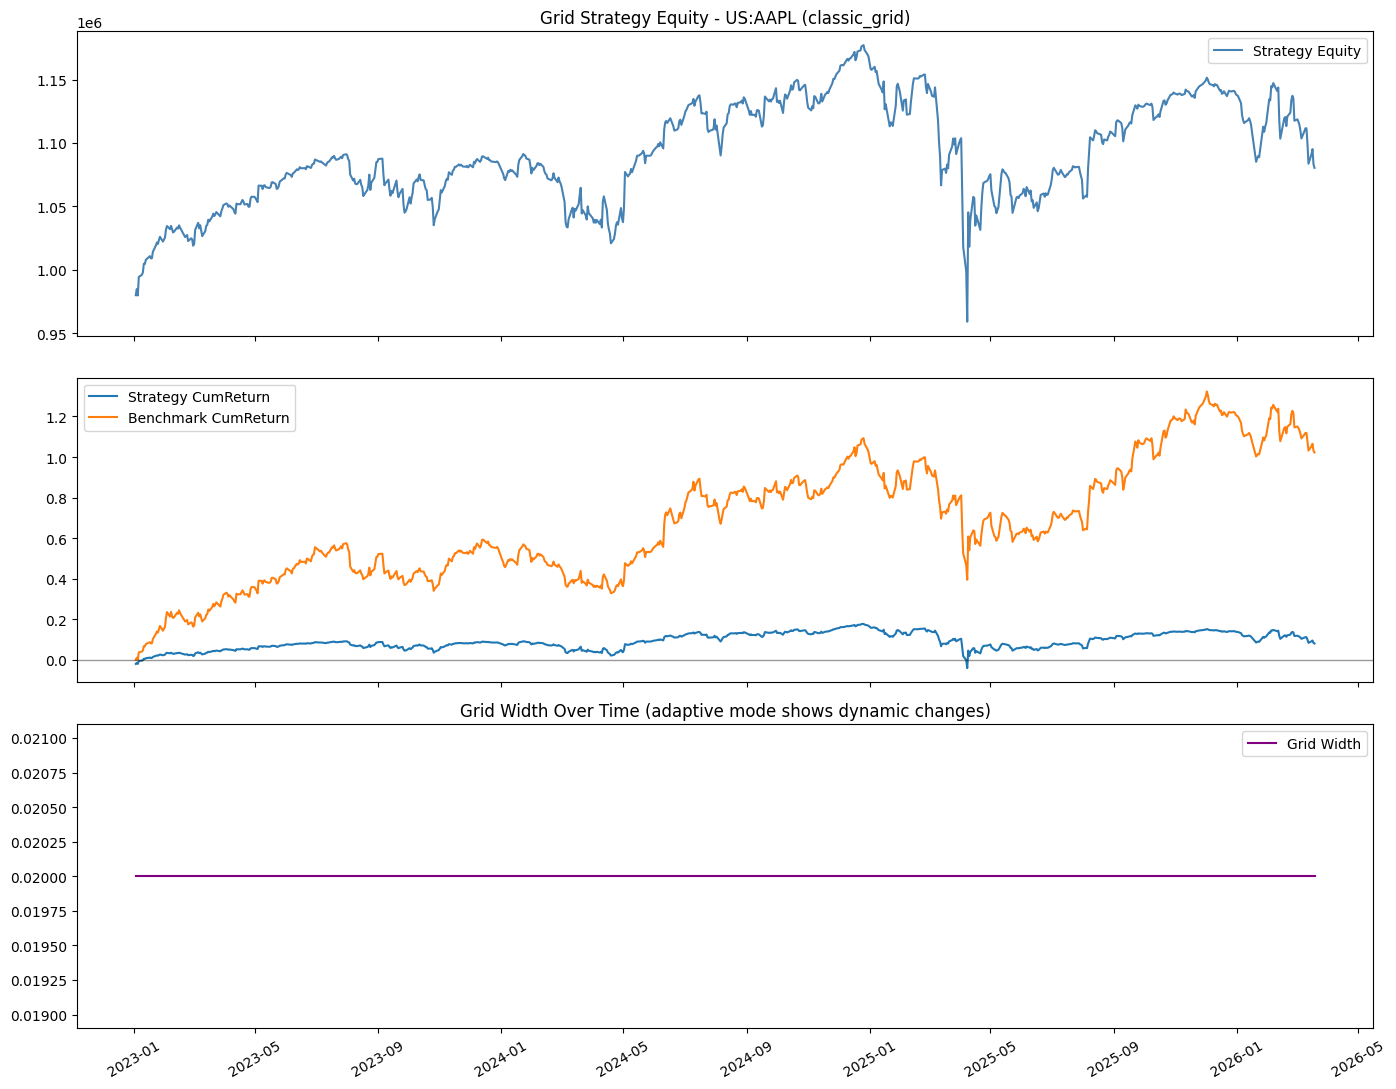

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

axes[0].plot(curve['trade_date'], curve['equity'], label='Strategy Equity', color='steelblue')
axes[0].set_title(f'Grid Strategy Equity - {symbol} ({strategy_mode})')
axes[0].legend()

axes[1].plot(curve['trade_date'], curve['strategy_cum_return'], label='Strategy CumReturn')
axes[1].plot(curve['trade_date'], curve['benchmark_cum_return'], label='Benchmark CumReturn')
axes[1].axhline(0, color='black', linewidth=1, alpha=0.4)
axes[1].legend()

axes[2].plot(curve['trade_date'], curve['grid_pct'], label='Grid Width', color='purple')
axes[2].set_title('Grid Width Over Time (adaptive mode shows dynamic changes)')
axes[2].legend()

plt.xticks(rotation=30)
plt.tight_layout()

In [8]:
trades_df.tail(30)

,trade_date,side,price,shares,fee,grid_pct
153,2025-08-08,SELL,219.939860,300,19.794587,0.02
154,2025-09-03,SELL,236.521986,200,14.191319,0.02
155,2025-09-10,BUY,231.980036,400,27.837604,0.02
156,2025-09-12,SELL,228.555147,300,20.569963,0.02
157,2025-09-17,SELL,238.276873,200,14.296612,0.02
158,2025-09-19,SELL,240.530307,200,14.431818,0.02
159,2025-09-22,SELL,247.579809,100,7.427394,0.02
160,2025-10-10,BUY,254.709463,400,30.565136,0.02
161,2025-10-17,SELL,247.300614,200,14.838037,0.02
162,2025-10-20,SELL,255.147805,100,7.654434,0.02
